# Housing Dataset - Exploratory Data Analysis (EDA)


#1. Import Required Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display options
pd.set_option('display.max_columns', None)

# Plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

# 2. Load the Dataset

In [2]:
# Load dataset
df = pd.read_csv("/content/Housing.csv")

In [3]:
# View first five rows
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# 3. Understand the Dataset

In [4]:
# Dataset shape
print("Rows and Columns:", df.shape)

Rows and Columns: (545, 13)


In [5]:
# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
# Summary statistics
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
# Check column names
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

# 4. Check Missing Values

In [8]:
# Missing values
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


# 5. Check Duplicate Records

In [9]:
# Number of duplicates
df.duplicated().sum()

np.int64(0)

# 6. Check Data Types

In [10]:
df.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,object
guestroom,object
basement,object
hotwaterheating,object
airconditioning,object


# 7. Univariate Analysis

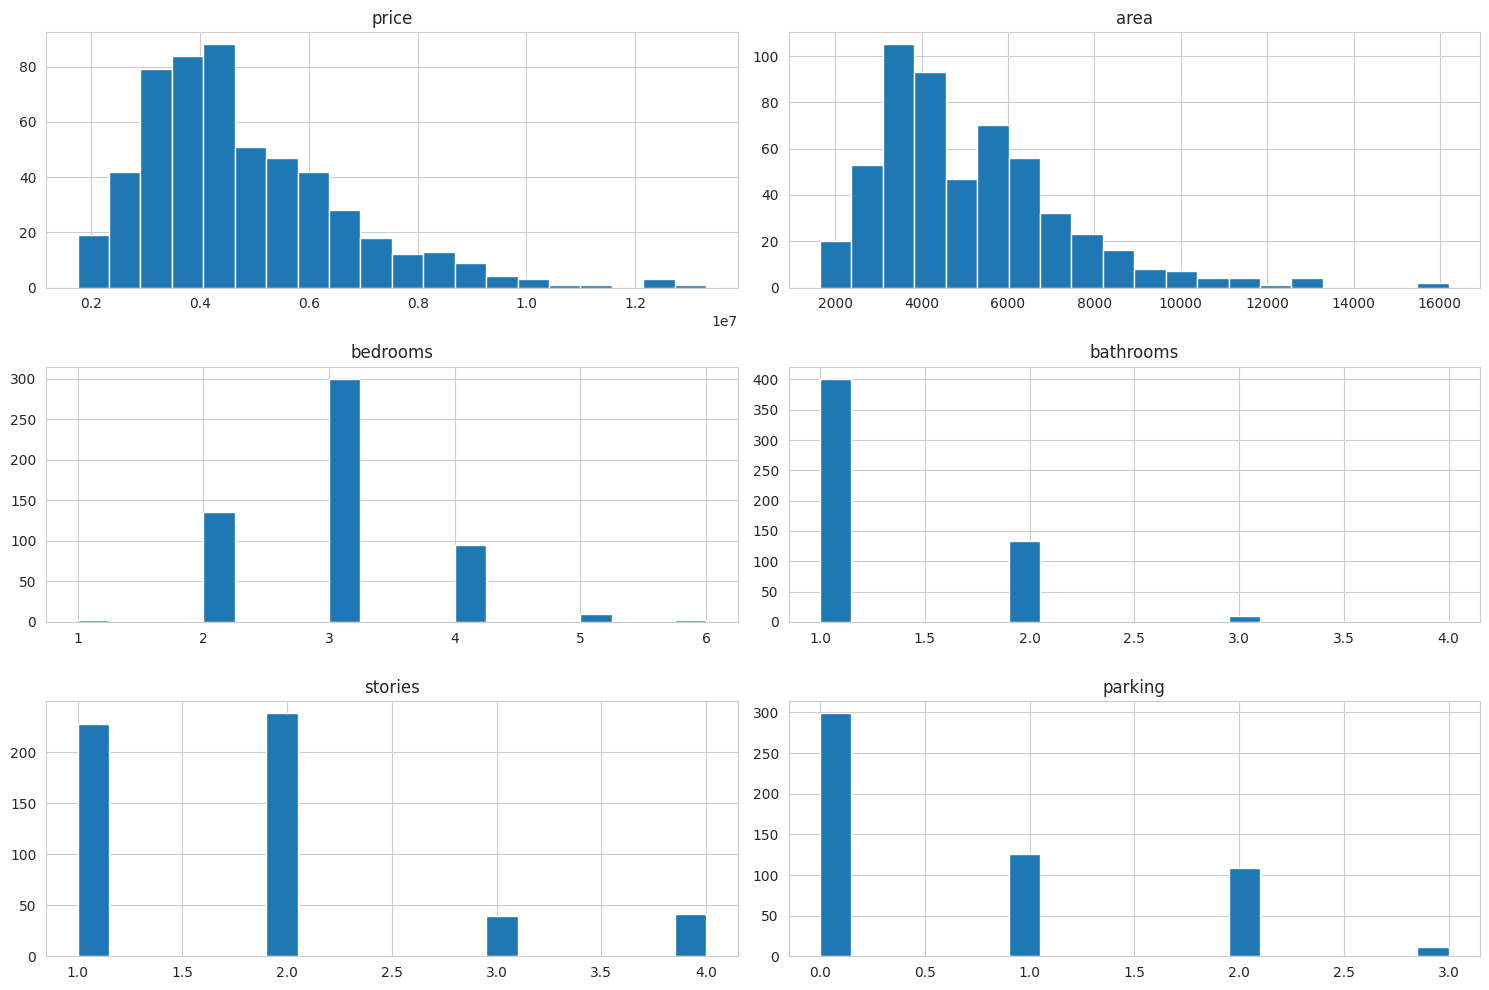

In [11]:
#Histograms
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

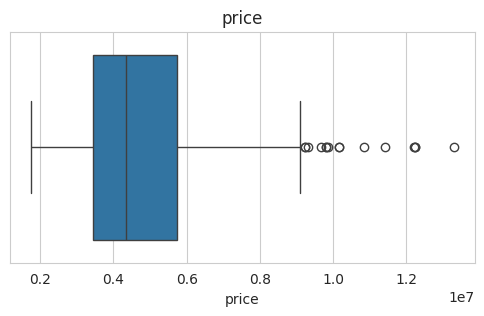

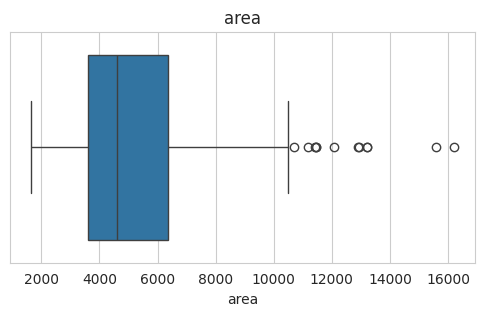

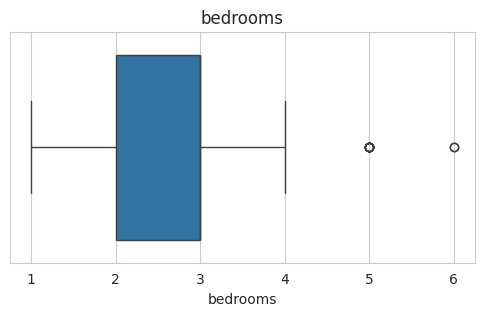

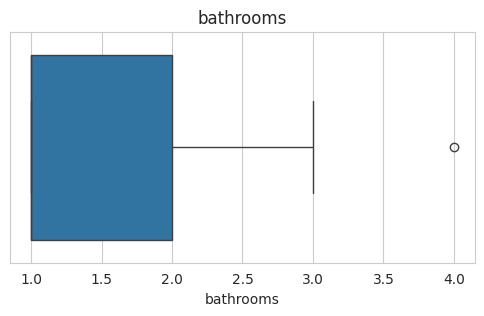

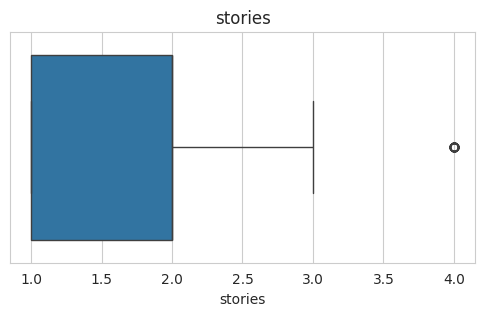

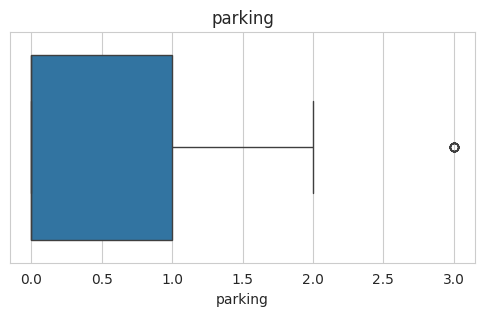

In [12]:
#Boxplots
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [13]:
#Categorical Features
categorical_cols = df.select_dtypes(include='object').columns

categorical_cols

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

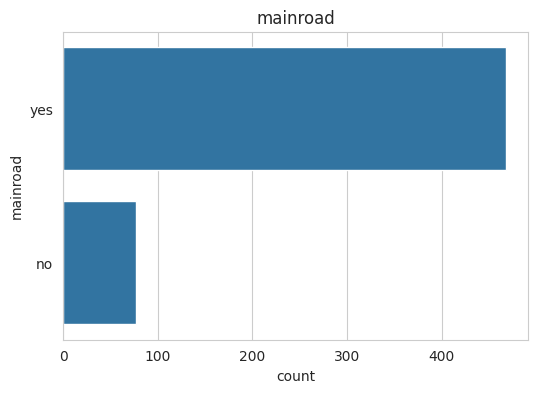

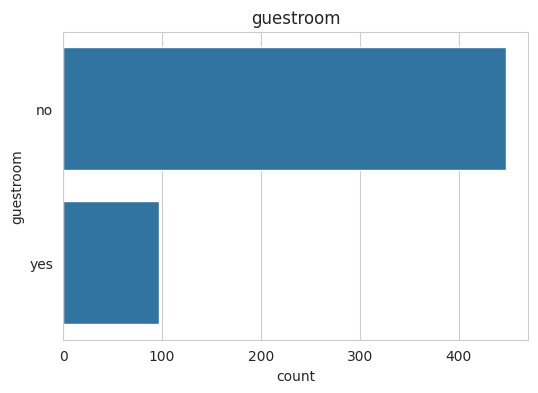

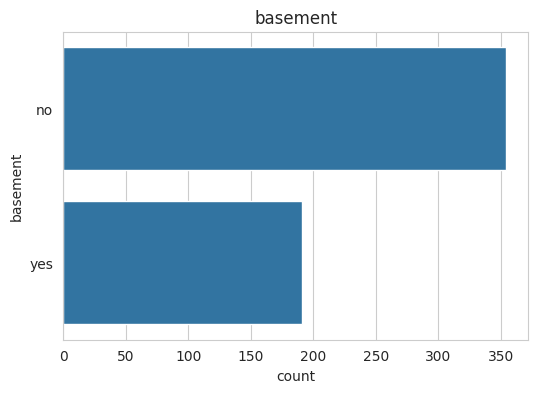

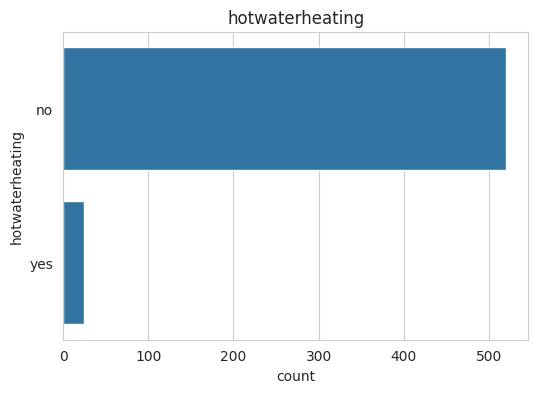

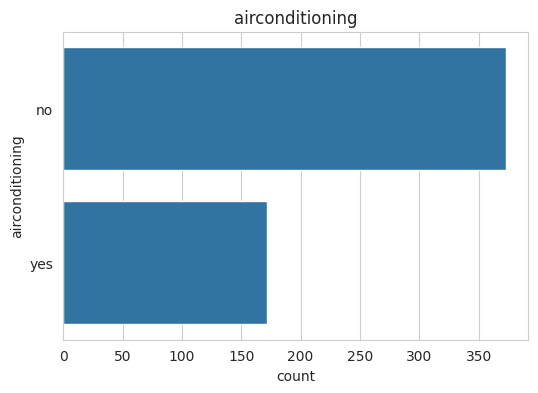

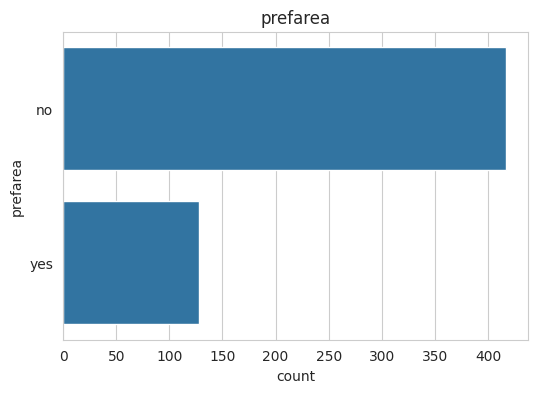

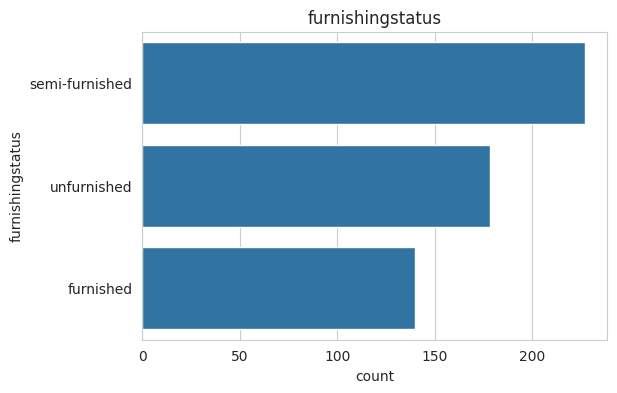

In [14]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.title(col)
    plt.show()

# 8. Bivariate Analysis

In [15]:
# Correlation Matrix First convert categorical variables.

df_encoded = df.copy()

for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

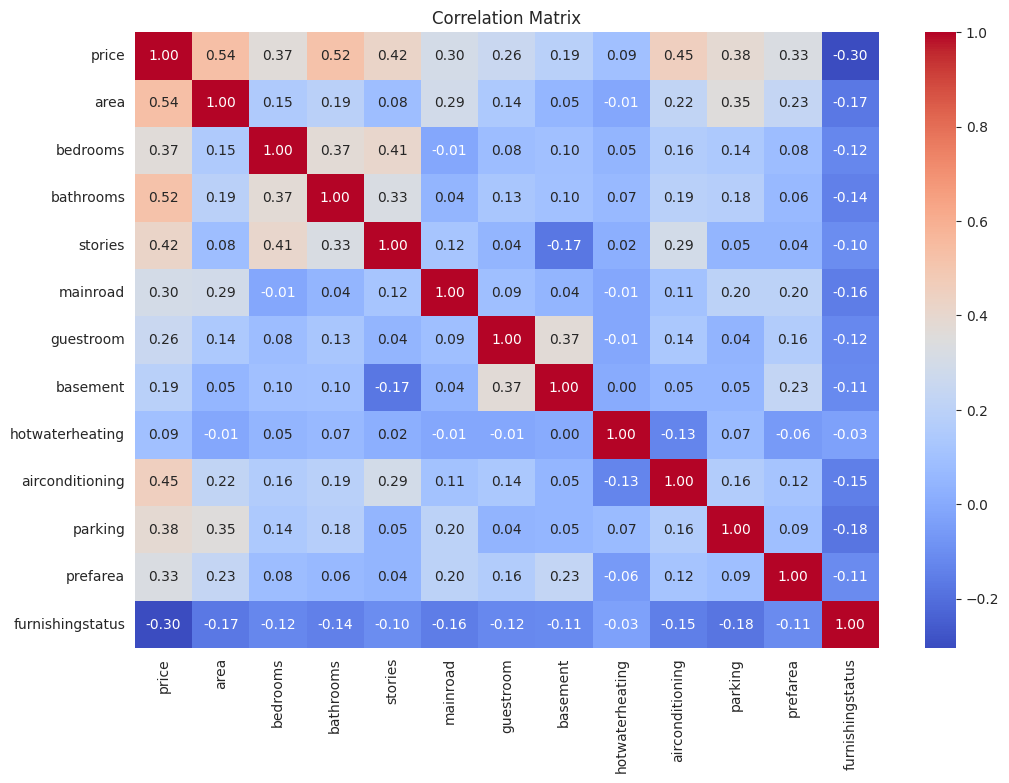

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(),
            annot=True,
            cmap='coolwarm',
            fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [17]:
# Relationship with House Price
correlation = df_encoded.corr()['price'].sort_values(ascending=False)

correlation

,price
price,1.000000
area,0.535997
bathrooms,0.517545
airconditioning,0.452954
stories,0.420712
parking,0.384394
bedrooms,0.366494
prefarea,0.329777
mainroad,0.296898
guestroom,0.255517


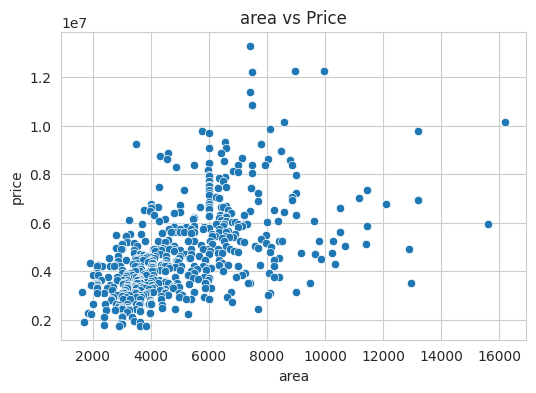

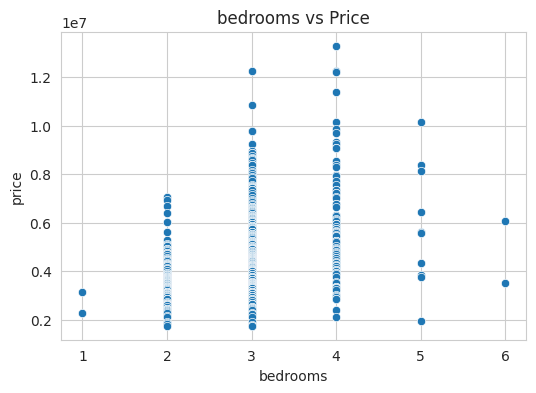

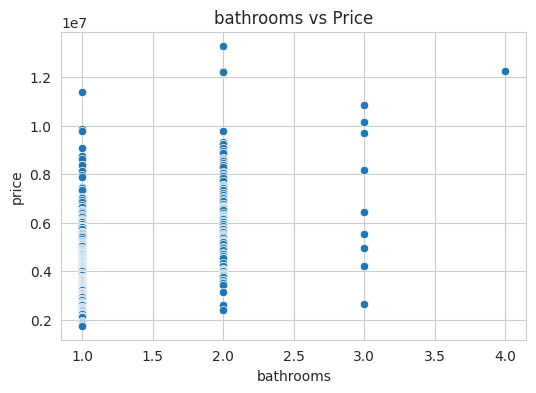

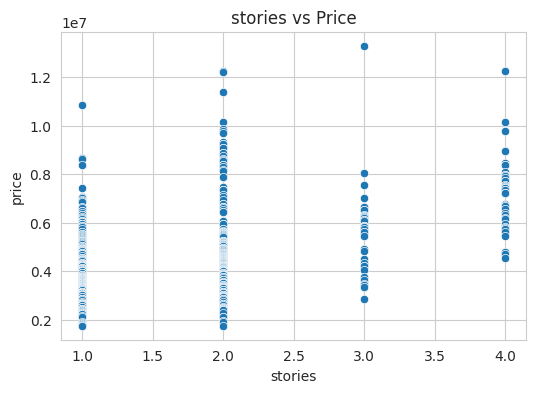

In [18]:
# Scatterplots
important_features = ['area','bedrooms','bathrooms','stories']

for feature in important_features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df,
                    x=feature,
                    y='price')
    plt.title(f"{feature} vs Price")
    plt.show()

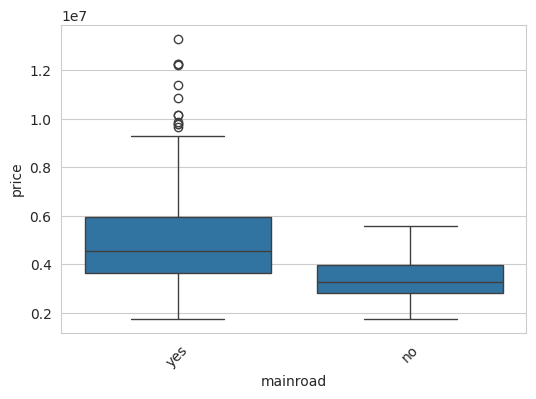

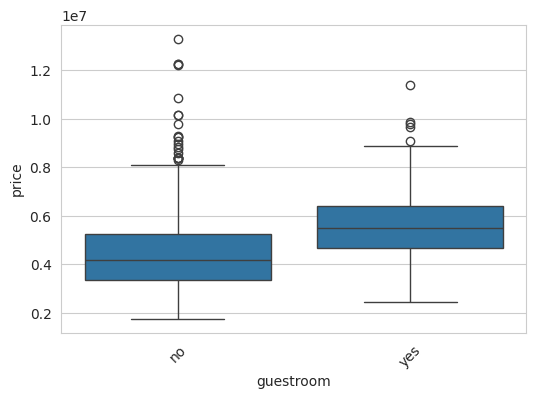

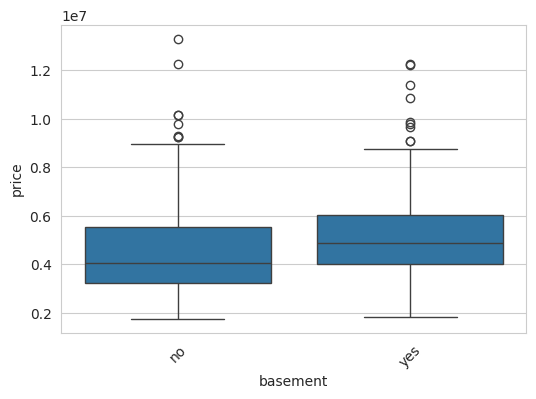

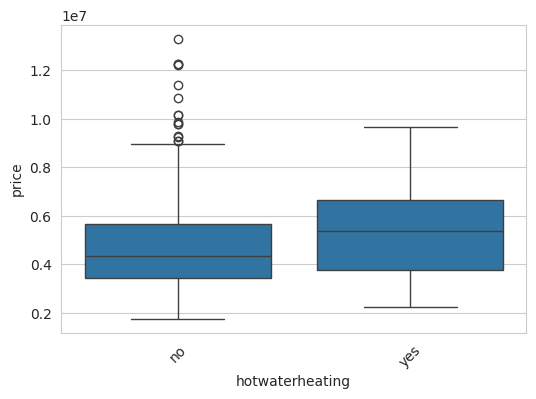

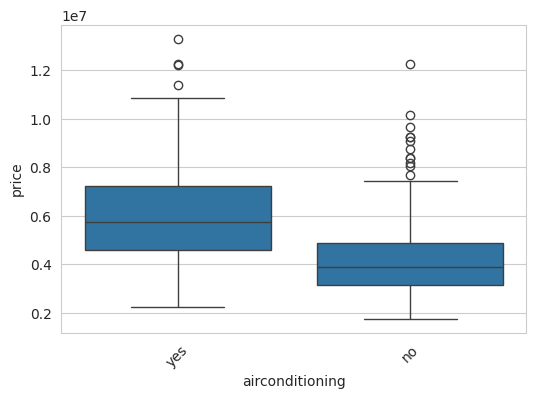

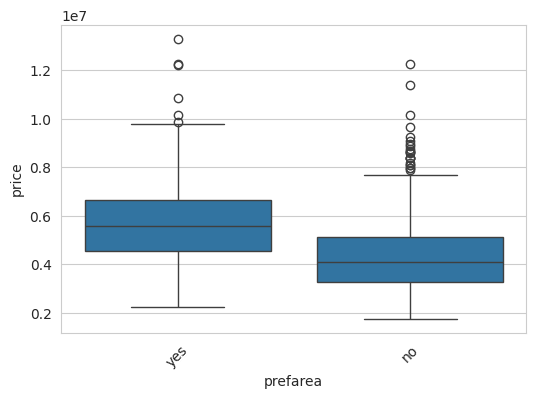

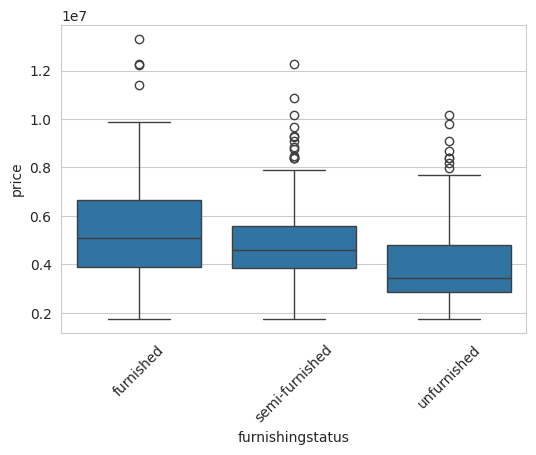

In [19]:
# Boxplots for Categorical Variables vs Price
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df,
                x=col,
                y='price')
    plt.xticks(rotation=45)
    plt.show()

# 9. Pairplot

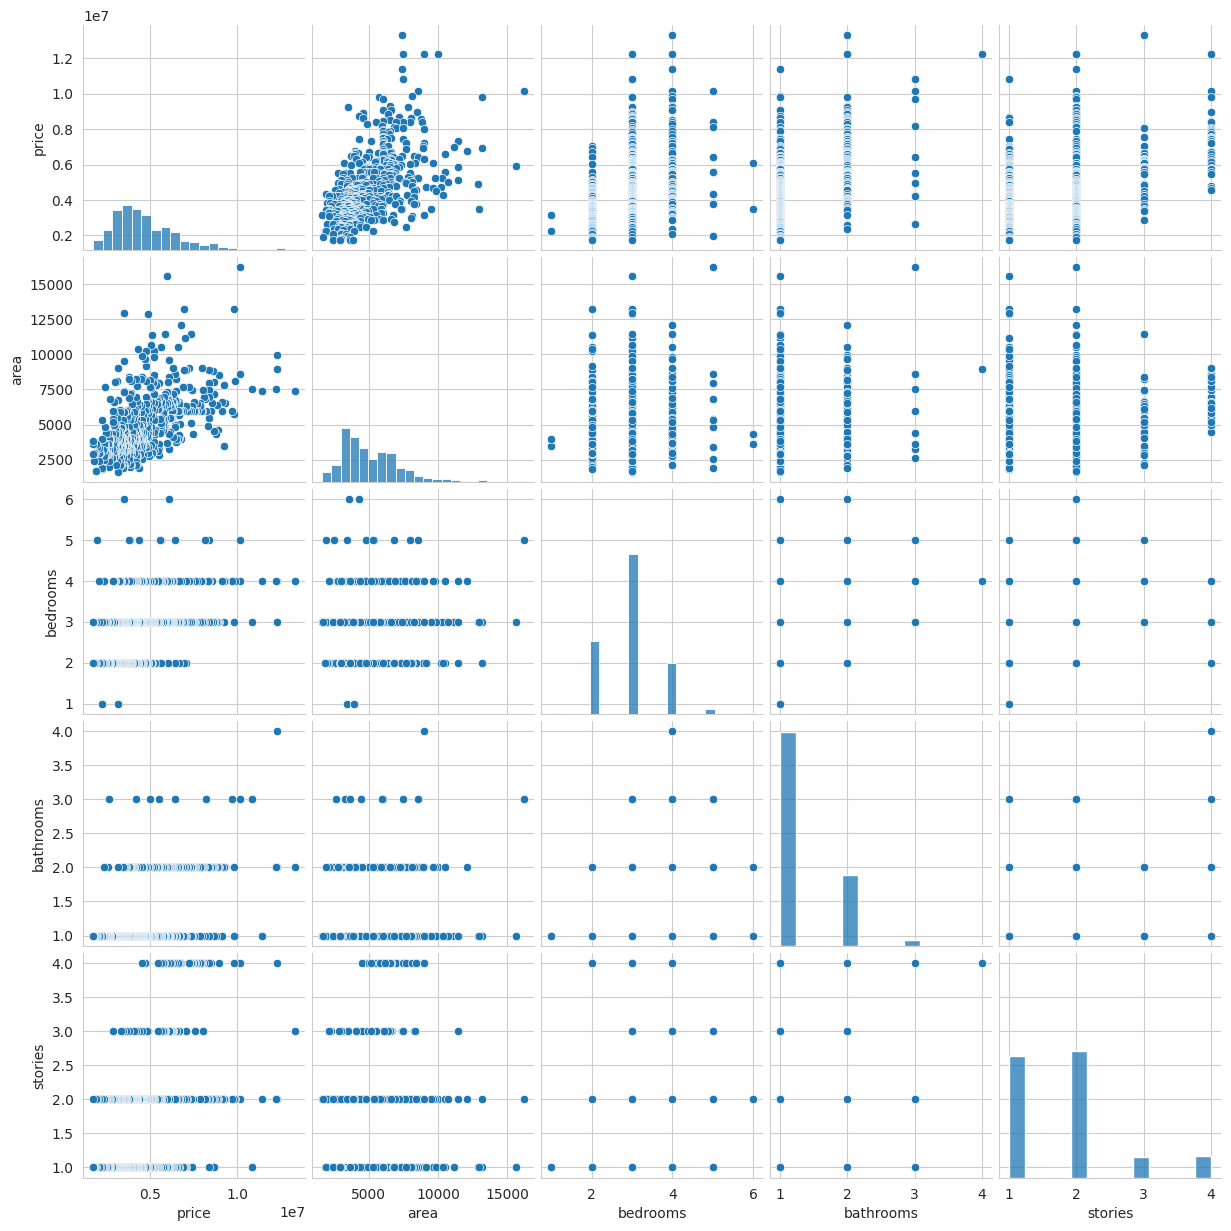

In [20]:
sns.pairplot(df[['price',
                 'area',
                 'bedrooms',
                 'bathrooms',
                 'stories']])

plt.show()

# 11. Feature Importance (Correlation with Price)

In [22]:
corr = df_encoded.corr()['price'].sort_values(ascending=False)

corr

,price
price,1.000000
area,0.535997
bathrooms,0.517545
airconditioning,0.452954
stories,0.420712
parking,0.384394
bedrooms,0.366494
prefarea,0.329777
mainroad,0.296898
guestroom,0.255517


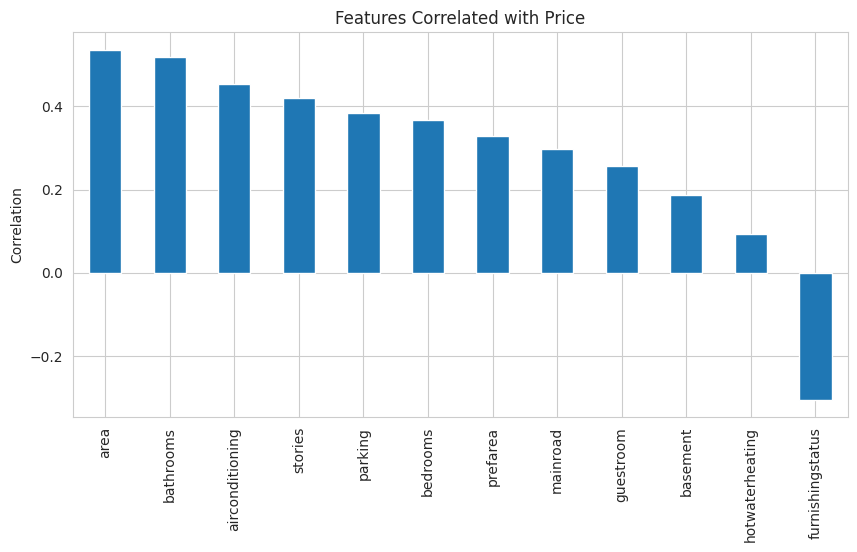

In [23]:
corr.drop('price').plot(kind='bar', figsize=(10,5))

plt.title("Features Correlated with Price")
plt.ylabel("Correlation")
plt.show()

In [24]:
# Save the cleaned dataset
df.to_csv("Housing_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
